<a href="https://colab.research.google.com/github/AJULUMEL/PCVK25_3F_07/blob/main/Week9_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DANDI AZRUL SYAHPUTRA

3F/07

2341720118

# TUGAS PRAKTIKUM

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install pytesseract

In [4]:
import cv2
import numpy as np
import pytesseract
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

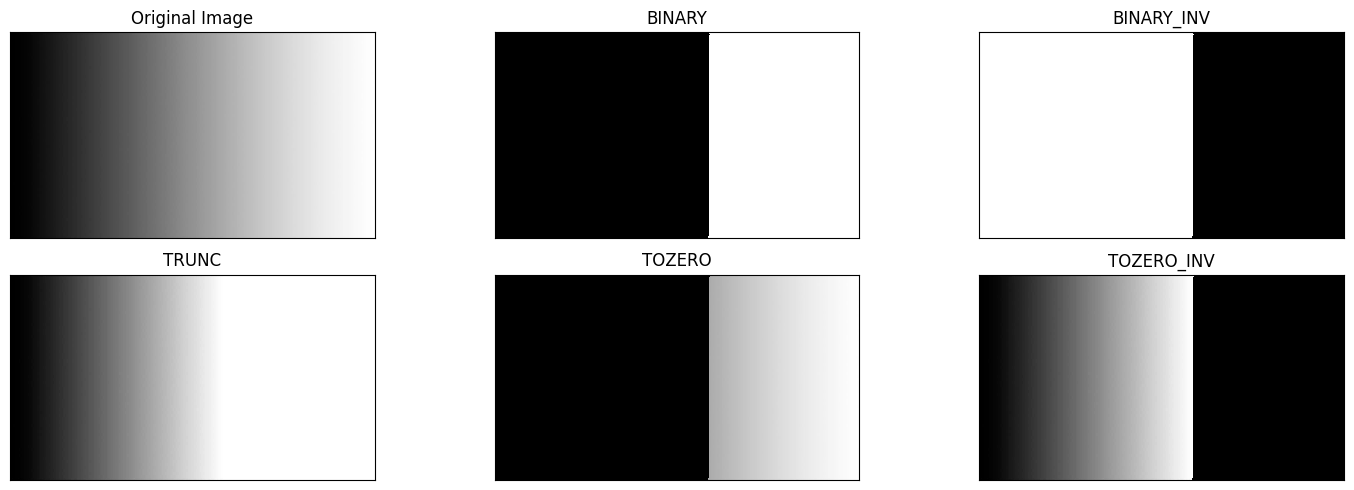

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pytesseract
import pandas as pd

# Membaca gambar
filename = '/content/gradient.jpg'
img = cv2.imread(filename, 0)  # dibaca sebagai grayscale

# Membuat salinan citra untuk tiap metode thresholding
thresh1 = img.copy()
thresh2 = img.copy()
thresh3 = img.copy()
thresh4 = img.copy()
thresh5 = img.copy()

# Nilai ambang (threshold) yang ditentukan
thresh = 170

# 1. Binary Threshold (tanpa library)
thresh1[img > thresh] = 255
thresh1[img <= thresh] = 0

# 2. Binary Threshold Inverse (tanpa library)
thresh2 = 255 - thresh1

# 3. Threshold Truncate (tanpa library)
thresh3[img > thresh] = thresh

# 4. Threshold ToZero (tanpa library)
thresh4[img <= thresh] = 0

# 5. Threshold ToZero Inverse (tanpa library)
thresh5[img > thresh] = 0

# Menyiapkan data untuk ditampilkan
titles = ['Original Image', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

# Menampilkan semua hasil
plt.figure(figsize=(15, 5))
for i in range(len(images)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], 'gray', interpolation='nearest')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()

Nilai threshold Otsu = 167


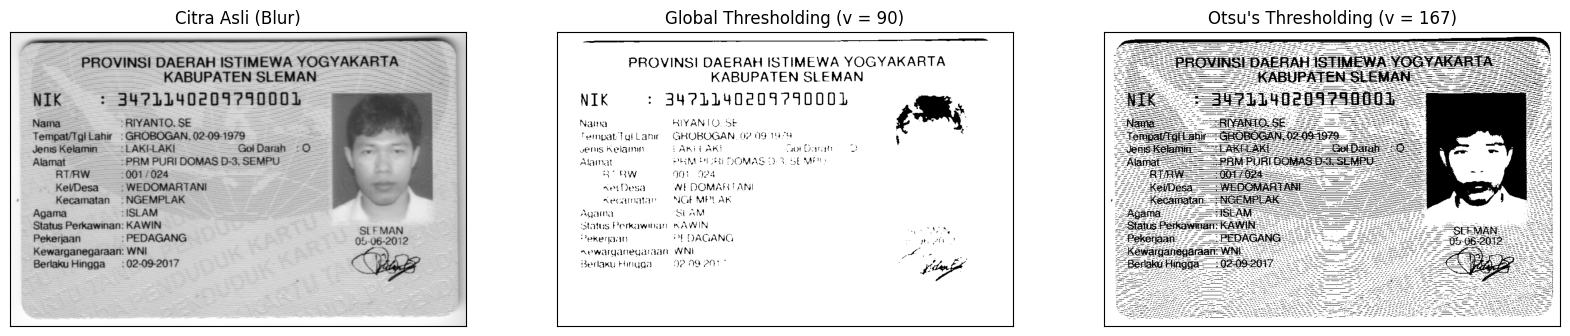

In [9]:
# ============================
# PRAKTIKUM 9 - Otsu's Thresholding (Tanpa Library)
# ============================

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Membaca citra KTP dalam grayscale
filename = '/content/drive/MyDrive/Colab Notebooks/PCVK25_3F_07/Pertemuan 9/ktp.png'
img = cv.imread(filename, 0)

# Gaussian blur untuk mengurangi noise
blur = cv.GaussianBlur(img, (5,5), 0)

# ------------------------------------------
# Fungsi Otsu manual (tanpa library)
# ------------------------------------------
def otsu(gray):
    pixel_number = gray.shape[0] * gray.shape[1]
    mean_weight = 1.0 / pixel_number
    his, bins = np.histogram(gray, np.arange(0,257))
    final_thresh = -1
    final_value = -1
    intensity_arr = np.arange(256)

    # Iterasi setiap kemungkinan threshold t (1–254)
    for t in bins[1:-1]:
        pcb = np.sum(his[:t])   # Jumlah pixel background
        pcf = np.sum(his[t:])   # Jumlah pixel foreground

        # Hindari pembagian nol
        if pcb == 0 or pcf == 0:
            continue

        Wb = pcb * mean_weight
        Wf = pcf * mean_weight
        mub = np.sum(intensity_arr[:t] * his[:t]) / float(pcb)
        muf = np.sum(intensity_arr[t:] * his[t:]) / float(pcf)

        # Variansi antar kelas (Between Class Variance)
        value = Wb * Wf * (mub - muf) ** 2

        # Simpan nilai threshold terbaik
        if value > final_value:
            final_thresh = t
            final_value = value

    # Buat citra hasil threshold
    final_img = gray.copy()
    print("Nilai threshold Otsu =", final_thresh)
    final_img[gray > final_thresh] = 255
    final_img[gray <= final_thresh] = 0
    return final_img, final_thresh

# ------------------------------------------
# Eksekusi Otsu Manual
# ------------------------------------------
otsu_biner, otsu_thresh = otsu(img)

# Global Threshold untuk perbandingan
ret, th1 = cv.threshold(blur, 90, 255, cv.THRESH_BINARY)

# ------------------------------------------
# Tampilkan hasil
# ------------------------------------------
x = f"Otsu's Thresholding (v = {otsu_thresh})"
titles = ['Citra Asli (Blur)', 'Global Thresholding (v = 90)', x]
citra3 = [blur, th1, otsu_biner]

plt.figure(figsize=(20,15))
for i in range(len(citra3)):
    plt.subplot(1,3,i+1)
    plt.imshow(citra3[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()


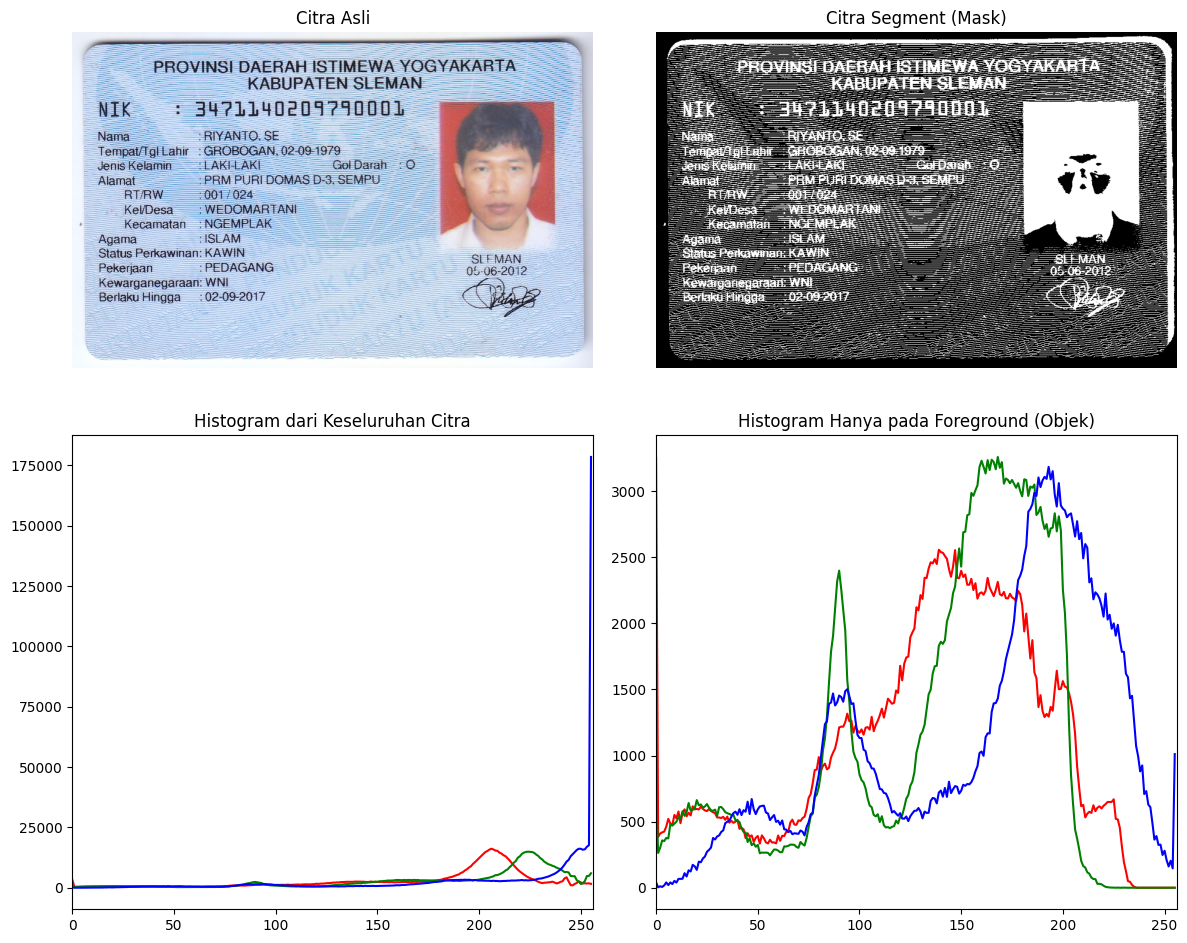

In [52]:
# --- Import library utama ---
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Baca citra ---
filename = '/content/drive/MyDrive/Colab Notebooks/PCVK25_3F_07/Pertemuan 9/ktp.png'
img = cv.imread(filename)

# Pastikan citra terbaca
if img is None:
    raise FileNotFoundError("Gambar tidak ditemukan. Pastikan path sudah benar!")

# Konversi ke RGB agar tampil benar di matplotlib
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# --- 2. Ubah ke grayscale untuk threshold ---
img_gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)

# --- 3. Buat mask (segmentasi sederhana) ---
# Threshold: bagian terang → background, bagian gelap (KTP) → foreground
ret3, mask = cv.threshold(img_gray, 200, 255, cv.THRESH_BINARY_INV)

# --- 4. Tampilkan citra asli dan mask ---
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1), plt.imshow(img)
plt.title('Citra Asli'), plt.axis('off')

plt.subplot(2, 2, 2), plt.imshow(mask, cmap='gray')
plt.title('Citra Segment (Mask)'), plt.axis('off')

# --- 5. Hitung histogram ---
color = ('r', 'g', 'b')

# Histogram keseluruhan citra (tanpa mask)
plt.subplot(2, 2, 3)
for i, col in enumerate(color):
    hist0 = cv.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(hist0, color=col)
plt.title('Histogram dari Keseluruhan Citra')
plt.xlim([0, 256])

# Histogram hanya foreground (menggunakan mask)
plt.subplot(2, 2, 4)
for i, col in enumerate(color):
    hist1 = cv.calcHist([img], [i], mask, [256], [0, 256])
    plt.plot(hist1, color=col)
plt.title('Histogram Hanya pada Foreground (Objek)')
plt.xlim([0, 256])

plt.tight_layout()
plt.show()


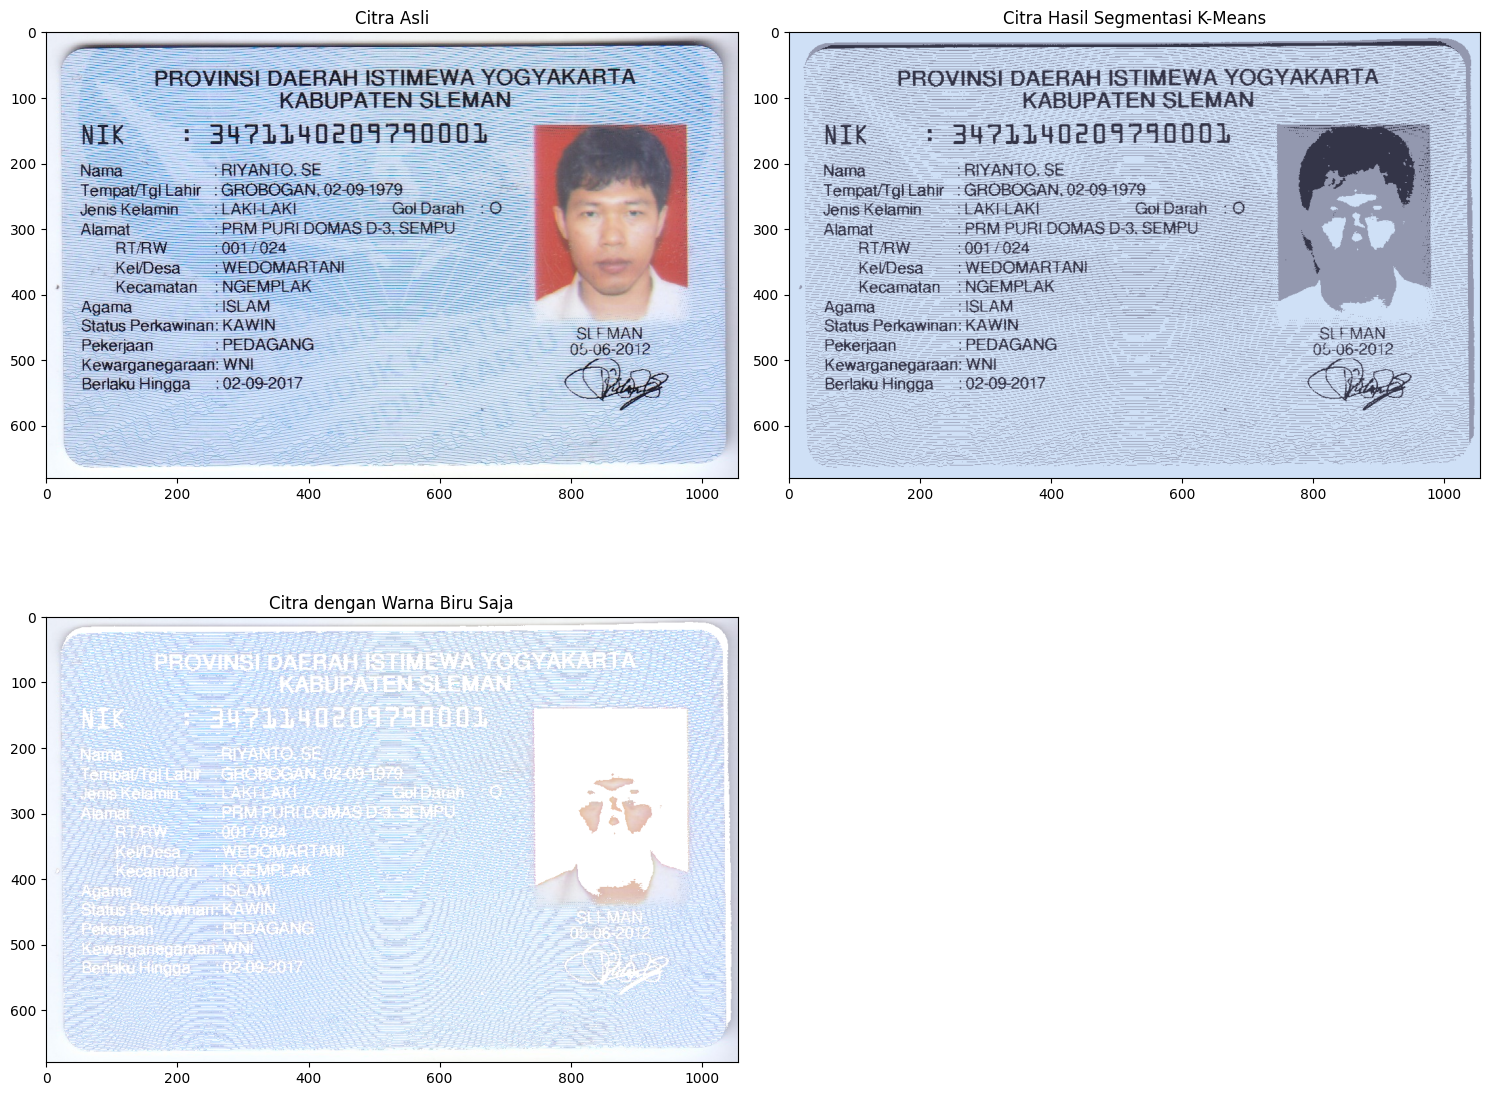

In [32]:
# ===============================================
# PRAKTIKUM 9 – Segmentasi Warna Biru pada KTP dengan K-Means
# ===============================================

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------
# 1️⃣ Membaca citra dan konversi ke RGB
# -----------------------------------------------
filename = '/content/drive/MyDrive/Colab Notebooks/PCVK25_3F_07/Pertemuan 9/ktp.png'
img = cv.imread(filename)

if img is None:
    raise FileNotFoundError("❌ Gambar tidak ditemukan, periksa path atau nama file!")

img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# -----------------------------------------------
# 2️⃣ Flattening array citra 3D → 2D (karena KMeans butuh array 2D)
# -----------------------------------------------
pixel_values = img.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

# -----------------------------------------------
# 3️⃣ Menentukan kriteria berhenti iterasi KMeans
# -----------------------------------------------
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 150, 0.1)

# -----------------------------------------------
# 4️⃣ Menentukan jumlah cluster
# -----------------------------------------------
# Pada KTP umumnya ada tiga warna dominan: biru, putih, dan kulit wajah.
k = 3
_, labels, centers = cv.kmeans(pixel_values, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

# Konversi titik centroid ke integer
centers = np.uint8(centers)
labels = labels.flatten()

# -----------------------------------------------
# 5️⃣ Membentuk citra hasil segmentasi berdasarkan centroid
# -----------------------------------------------
segmented_image = centers[labels]
segmented_image = segmented_image.reshape(img.shape)

# -----------------------------------------------
# 6️⃣ Menentukan cluster biru (dengan cara mendeteksi warna centroid)
# -----------------------------------------------
# Centroid dengan nilai B paling tinggi dianggap warna biru
blue_cluster = np.argmax(centers[:, 2])  # indeks cluster warna biru

# Membuat mask: hanya cluster biru yang ditampilkan
masked_image = np.copy(img)
masked_image0 = masked_image.reshape((-1, 3))
masked_image0[labels != blue_cluster] = [255, 255, 255]  # selain biru jadi putih
masked_image0 = masked_image0.reshape(img.shape)

# -----------------------------------------------
# 7️⃣ Menampilkan hasil
# -----------------------------------------------
plt.figure(figsize=(15,12))
plt.subplot(2,2,1), plt.imshow(img), plt.title('Citra Asli')
plt.subplot(2,2,2), plt.imshow(segmented_image), plt.title('Citra Hasil Segmentasi K-Means')
plt.subplot(2,2,3), plt.imshow(masked_image0), plt.title('Citra dengan Warna Biru Saja')
plt.tight_layout()
plt.show()


In [50]:
!pip install pytesseract
!sudo apt-get install tesseract-ocr-ind

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr-ind is already the newest version (1:4.00~git30-7274cfa-1.1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
